In [ ]:
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon
import pandas as pdb
import healpy as hp
import pandas as pd

In [ ]:

def healpix_to_geodataframe(nside: int, pixel_id: int | list[int] | str = 'all', order: str = 'NESTED') -> gpd.GeoDataFrame:
    """
    Converts HEALPix pixel(s) to a GeoDataFrame containing boundary 
    polygon(s) in the WGS84 Geographic CRS (EPSG:4326).

    Args:
        nside: The HEALPix resolution parameter.
        pixel_id: The index of a HEALPix pixel, a list of pixel indices, or 'all' to generate all pixels.
        order: The pixel ordering scheme ('NESTED' or 'RING').

    Returns:
        A geopandas.GeoDataFrame with row(s) representing the cell geometry/geometries.
    """
    
    # Handle 'all' option - generate all pixels for the given nside
    if pixel_id == 'all':
        npix = hp.nside2npix(nside)
        pixel_ids = list(range(npix))
    # Handle single pixel_id or list of pixel_ids
    elif isinstance(pixel_id, int):
        pixel_ids = [pixel_id]
    else:
        pixel_ids = pixel_id
    
    data = []
    
    for pid in pixel_ids:
        # 1. Get vertices in spherical coordinates (theta, phi)
        # theta (colatitude) is 0 at North Pole, pi at South Pole
        # phi (longitude) is 0 to 2*pi
        # hp.boundaries returns shape (2, n_vertices) where first row is theta, second is phi
        vertices = hp.boundaries(nside, pid, step=1, nest=(order == 'NESTED'))
        vertices_theta = vertices[0]
        vertices_phi = vertices[1]

        # 2. Convert spherical coordinates to geographic (lat, lon) in degrees
        # Latitude (lat): 90 - degrees(theta)
        # Longitude (lon): degrees(phi)
        vertices_lat = np.degrees(np.pi/2 - vertices_theta)
        vertices_lon = np.degrees(vertices_phi)
        
        # 3. Handle longitude wrapping (for cells crossing the anti-meridian,
        # ensuring longitudes are in the range [-180, 180])
        vertices_lon[vertices_lon > 180] -= 360

        # 4. Create Shapely Polygon from (lon, lat) coordinates
        # Shapely/GeoPandas expects (lon, lat) order
        cell_polygon = Polygon(zip(vertices_lon, vertices_lat))

        # 5. Add to data list
        data.append({
            'pixel_id': pid,
            'nside': nside,
            'order': order,
            'geometry': cell_polygon
        })
    
    # Create GeoDataFrame
    gdf = gpd.GeoDataFrame(
        data,
        crs='EPSG:4326' # Standard WGS84 Geographic CRS
    )
    
    return gdf

In [ ]:
pd.options.display.max_colwidth = 1000

In [ ]:
# Example with all pixels for nside=8 (generates 768 pixels)
gdf_multi = healpix_to_geodataframe(nside=4, pixel_id='all')
gdf_multi

,pixel_id,nside,order,geometry
0,0,4,NESTED,"POLYGON ((38.19719 51.80281, 31.38661 43.02662, 40.51423 49.48577, 46.97338 58.61339, 38.19719 51.80281))"
1,1,4,NESTED,"POLYGON ((41.25719 62.43283, 38.19719 51.80281, 46.97338 58.61339, 49.90703 69.32783, 41.25719 62.43283))"
2,2,4,NESTED,"POLYGON ((27.56717 48.74281, 20.67217 40.09297, 31.38661 43.02662, 38.19719 51.80281, 27.56717 48.74281))"
3,3,4,NESTED,"POLYGON ((30.19753 59.80247, 27.56717 48.74281, 38.19719 51.80281, 41.25719 62.43283, 30.19753 59.80247))"
4,4,4,NESTED,"POLYGON ((39.45497 73.65722, 41.25719 62.43283, 49.90703 69.32783, 48.66617 80.3197, 39.45497 73.65722))"
...,...,...,...,...
187,187,4,NESTED,"POLYGON ((-49.90703 69.32783, -48.66617 80.3197, -39.45497 73.65722, -41.25719 62.43283, -49.90703 69.32783))"
188,188,4,NESTED,"POLYGON ((-38.19719 51.80281, -41.25719 62.43283, -30.19753 59.80247, -27.56717 48.74281, -38.19719 51.80281))"
189,189,4,NESTED,"POLYGON ((-31.38661 43.02662, -38.19719 51.80281, -27.56717 48.74281, -20.67217 40.09297, -31.38661 43.02662))"
190,190,4,NESTED,"POLYGON ((-46.97338 58.61339, -49.90703 69.32783, -41.25719 62.43283, -38.19719 51.80281, -46.97338 58.61339))"


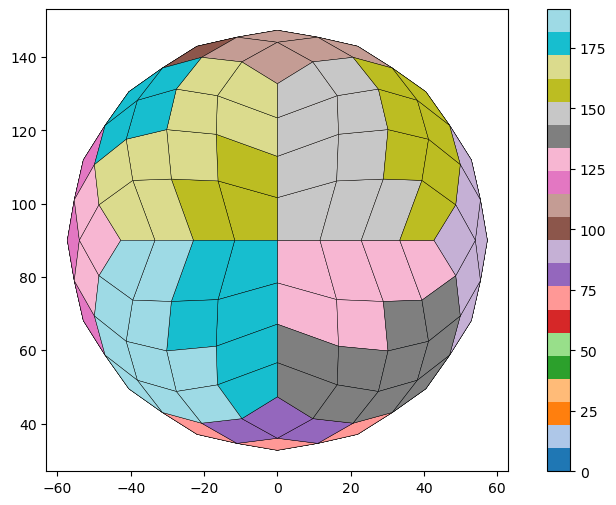

In [ ]:
ax = gdf_multi.plot(
    column='pixel_id',    # use 'column' not 'color'
    cmap='tab20', 
    legend=True, 
    figsize=(10, 6), 
    linewidth=0.3, 
    edgecolor='black'
)
ax.set_aspect('equal')

In [ ]:

def generate_wgs84_polygons(centers: list[tuple[float, float]], 
                            n_sides: int, 
                            radius_deg: float, 
                            rotation_deg: float = 0.0) -> gpd.GeoDataFrame:
    """
    Generates a GeoDataFrame containing regular N-sided polygons 
    (e.g., hexagons, squares) centered at specified lon/lat coordinates.

    NOTE: The 'radius_deg' defines the size in degrees of longitude/latitude space.
          This function is for visual/modeling purposes where WGS84 coordinates 
          are used as a flat Cartesian plane (non-geographical analysis).

    Args:
        centers: A list of tuples, where each tuple is (longitude, latitude) 
                 for the center of a polygon.
        n_sides: The number of sides of the regular polygon (e.g., 6 for a hexagon).
        radius_deg: The radius of the polygon in degrees (distance from center 
                    to a vertex).
        rotation_deg: The rotation angle of the polygon in degrees 
                      (0 degrees means a side or vertex points North/East).

    Returns:
        A geopandas.GeoDataFrame with the generated polygons, CRS is WGS84 (EPSG:4326).
    """
    polygons_data = []
    
    # Convert rotation angle to radians
    rotation_rad = np.radians(rotation_deg)
    
    # Calculate the angles for the vertices
    # Start angle adjusts for the initial rotation
    angles = np.linspace(0, 2 * np.pi, n_sides, endpoint=False) + rotation_rad
    
    for i, (center_lon, center_lat) in enumerate(centers):
        
        # Calculate x and y coordinates of vertices relative to the center
        # Since we treat lon/lat as a Cartesian plane, use simple trig:
        x_vertices = center_lon + radius_deg * np.cos(angles)
        y_vertices = center_lat + radius_deg * np.sin(angles)
        
        # Create Shapely Polygon from (lon, lat) coordinates
        # zip(x_vertices, y_vertices) provides (lon, lat) tuples
        polygon = Polygon(zip(x_vertices, y_vertices))
        
        polygons_data.append({
            'id': i,
            'center_lon': center_lon,
            'center_lat': center_lat,
            'geometry': polygon
        })

    # Create GeoDataFrame with WGS84 CRS
    gdf = gpd.GeoDataFrame(
        polygons_data,
        crs='EPSG:4326' 
    )
    
    return gdf

<Axes: >

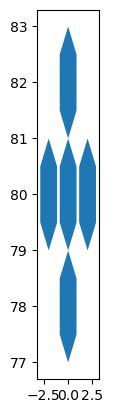

In [ ]:

# --- Example Usage (Do not run) ---
# Define centers for a small cluster similar to the logo:
center_pts = np.array([
    (0.0, 0.0), 
    (2.0, 0.0), 
    (-2.0, 0.0), 
    (0.0, 2.0),
    (0.0, -2.0)
])

fixed_number = 80.0  # adjust this value as needed
center_pts[:, 1] += fixed_number
center_pts

# Generate Hexagons (n_sides=6) with a radius of 1.0 degree, rotated by 30 degrees
gdf_hexagons = generate_wgs84_polygons(
    centers=center_pts, 
    n_sides=6, 
    radius_deg=1.0, 
    rotation_deg=30.0
)

gdf_hexagons.plot()